

**Ciencia de datos 12-13 hrs.**

**Docente:** Zuriel Dathan Mora Felix

**Alumnos:** Bejarano Felix Bernardo Daniel, de la Mora Morales Ricardo

**Archivo analizado:** `datos_estacion_25015_2025.csv`

---

# Índice

1. [Carga, inspección y preparación](#carga-inspeccion-y-preparacion)
2. [Selección de variables numéricas y preparación del análisis](#seleccion-de-variables-numericas-y-preparacion-del-analisis)
3. [Estadística descriptiva](#estadistica-descriptiva)
4. [Histogramas: distribución y forma](#histogramas-distribucion-y-forma)
5. [Diagramas de densidad: concentración y dispersión](#diagramas-de-densidad-concentracion-y-dispersion)
6. [Boxplot: cuartiles, IQR y outliers](#boxplot-cuartiles-iqr-y-outliers)
7. [Análisis de tendencias temporal](#analisis-de-tendencias-temporal)
8. [Comentarios y conclusiones](#comentarios-y-conclusiones)

# Análisis estadístico de datos meteorológicos 2025

Este notebook analiza el archivo `datos_estacion_25015_2025.csv` con estadística descriptiva, detección de valores atípicos, histogramas, densidad, boxplots y análisis temporal.

Variables analizadas: `Precip`, `Evap`, `Tmax` y `Tmin`.

In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

# Cargamos el dataset y realizamos un análisis exploratorio inicial para entender su estructura, tipos de datos, valores faltantes, etc.
df = pd.read_csv("datos_estacion_25015_2025.csv")
df["Fecha"] = pd.to_datetime(df["Fecha"])
df = df.sort_values("Fecha").reset_index(drop=True)

# Identificamos las columnas numéricas y la columna temporal para un análisis más detallado.
numericas = df.select_dtypes(include="number").columns.tolist()
temporal = "Fecha"


print(f"Filas: {df.shape[0]}, columnas: {df.shape[1]}")
print(f"Rango temporal: {df[temporal].min().date()} a {df[temporal].max().date()}")
print(f"Variables numéricas: {numericas}")

Filas: 365, columnas: 5
Rango temporal: 2025-01-01 a 2025-12-31
Variables numéricas: ['Precip', 'Evap', 'Tmax', 'Tmin']


<a id="carga-inspeccion-y-preparacion"></a>
## 1. Carga, inspección y preparación

En esta sección se revisa la estructura del archivo, los tipos de datos y los valores faltantes. El conjunto es temporal porque incluye una columna de fecha diaria durante todo 2025.

In [42]:
# Realizamos un análisis exploratorio inicial para entender la estructura del dataset, tipos de datos, valores faltantes, etc.
print(df.head())
print(df.dtypes.to_frame("tipo"))
print(df.isna().sum().to_frame("faltantes"))

# Calculamos un resumen estadístico para cada variable numérica, incluyendo medidas de tendencia central, dispersión y percentiles.
def resumen_estadistico(serie: pd.Series) -> pd.Series:
    datos = serie.dropna()
    q1 = datos.quantile(0.25)
    q3 = datos.quantile(0.75)
    iqr = q3 - q1
    moda = datos.mode()
    return pd.Series({
        "media": datos.mean(),
        "mediana": datos.median(),
        "moda": ", ".join(map(str, moda.tolist())) if len(moda) else "Sin moda",
        "minimo": datos.min(),
        "maximo": datos.max(),
        "rango": datos.max() - datos.min(),
        "varianza": datos.var(),
        "desviacion_std": datos.std(),
        "q1": q1,
        "q3": q3,
        "iqr": iqr,
    })

# Calculamos outliers utilizando la regla del IQR para cada variable numérica y resumimos los resultados en un DataFrame.
def outliers_iqr(df_local: pd.DataFrame, columna: str) -> pd.DataFrame:
    datos = df_local[columna].dropna()
    q1 = datos.quantile(0.25)
    q3 = datos.quantile(0.75)
    iqr = q3 - q1
    limite_inferior = q1 - 1.5 * iqr
    limite_superior = q3 + 1.5 * iqr
    mascara = (df_local[columna] < limite_inferior) | (df_local[columna] > limite_superior)
    return df_local.loc[mascara, ["Fecha", columna]].copy()

       Fecha  Precip  Evap  Tmax  Tmin
0 2025-01-01     0.0  1.08  29.5  11.0
1 2025-01-02     0.0  1.40  31.0  12.0
2 2025-01-03     0.0  0.97  30.0  13.0
3 2025-01-04     0.0  1.37  30.0  14.0
4 2025-01-05     0.0  1.67  30.0  13.0
                  tipo
Fecha   datetime64[us]
Precip         float64
Evap           float64
Tmax           float64
Tmin           float64
        faltantes
Fecha           0
Precip          0
Evap           52
Tmax            0
Tmin            0


<a id="seleccion-de-variables-numericas-y-preparacion-del-analisis"></a>
## 2. Selección de variables numéricas y preparación del análisis

Se analizan todas las variables numéricas del archivo. Como el conjunto incluye fecha, el estudio de tendencias se hará con series temporales por mes para reducir el ruido diario y mostrar mejor el comportamiento general.

In [41]:
# Generamos un resumen estadístico para cada variable numérica y lo mostramos en un DataFrame ordenado.    
resumen = pd.DataFrame({col: resumen_estadistico(df[col]) for col in numericas}).T
resumen = resumen[["media", "mediana", "moda", "minimo", "maximo", "rango", "varianza", "desviacion_std", "q1", "q3", "iqr"]]
display(resumen.round(3))

# Calculamos outliers utilizando la regla del IQR para cada variable numérica y resumimos los resultados en un DataFrame.
outlier_resumen = []
for col in numericas:
        outliers = outliers_iqr(df, col)
        datos = df[col].dropna()
        q1 = datos.quantile(0.25)
        q3 = datos.quantile(0.75)
        iqr = q3 - q1
        limite_inferior = q1 - 1.5 * iqr
        limite_superior = q3 + 1.5 * iqr
        outlier_resumen.append({
                    "variable": col,
                    "outliers": len(outliers),
                    "limite_inferior": limite_inferior,
                    "limite_superior": limite_superior,
                })

# Mostramos el resumen de outliers para cada variable numérica.
outlier_resumen = pd.DataFrame(outlier_resumen)
display(outlier_resumen.round(3))

,media,mediana,moda,minimo,maximo,rango,varianza,desviacion_std,q1,q3,iqr
Precip,1.602521,0.0,0.0,0.0,62.5,62.5,44.294436,6.655407,0.0,0.0,0.0
Evap,4.711821,4.4,5.1,0.3,19.25,18.95,7.983165,2.82545,2.5,6.45,3.95
Tmax,34.728767,35.5,36.0,20.0,41.5,21.5,12.404253,3.521967,33.0,37.0,4.0
Tmin,19.923288,20.0,24.0,8.0,29.0,21.0,28.227616,5.312967,15.0,25.0,10.0


,variable,outliers,limite_inferior,limite_superior
0,Precip,69,0.000,0.000
1,Evap,3,-3.425,12.375
2,Tmax,8,27.000,43.000
3,Tmin,0,0.000,40.000


<a id="estadistica-descriptiva"></a>
## 3. Estadística descriptiva

La desviación estándar resume la dispersión respecto a la media: valores altos indican mayor variabilidad, mientras que valores bajos indican datos más concentrados.

En este conjunto, `Precip` presenta una media mayor que la mediana, esto nos puede indicar que la mayor parte de los días no hubo lluvia y algunos eventos intensos empujan la media hacia arriba. `Evap` muestra asimetría leve a la derecha, `Tmax` una ligera asimetría a la izquierda por algunos días fríos, y `Tmin` aparece más centrada y estable.

Los valores atípicos pueden afectar especialmente la media y la desviación estándar. En `Precip`, la regla IQR identifica muchos outliers porque la distribución está muy concentrada en cero; en `Evap` y `Tmax` aparecen pocos casos extremos, y en `Tmin` no se detectan outliers por este criterio.

<a id="histogramas-distribucion-y-forma"></a>
## Histogramas: distribución y forma


C:\Users\moraa\AppData\Local\Temp\ipykernel_27612\3063850493.py:13: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax_hist.legend(fontsize=10)
C:\Users\moraa\AppData\Local\Temp\ipykernel_27612\3063850493.py:13: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax_hist.legend(fontsize=10)
C:\Users\moraa\AppData\Local\Temp\ipykernel_27612\3063850493.py:13: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax_hist.legend(fontsize=10)
C:\Users\moraa\AppData\Local\Temp\ipykernel_27612\3063850493.py:13: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored 

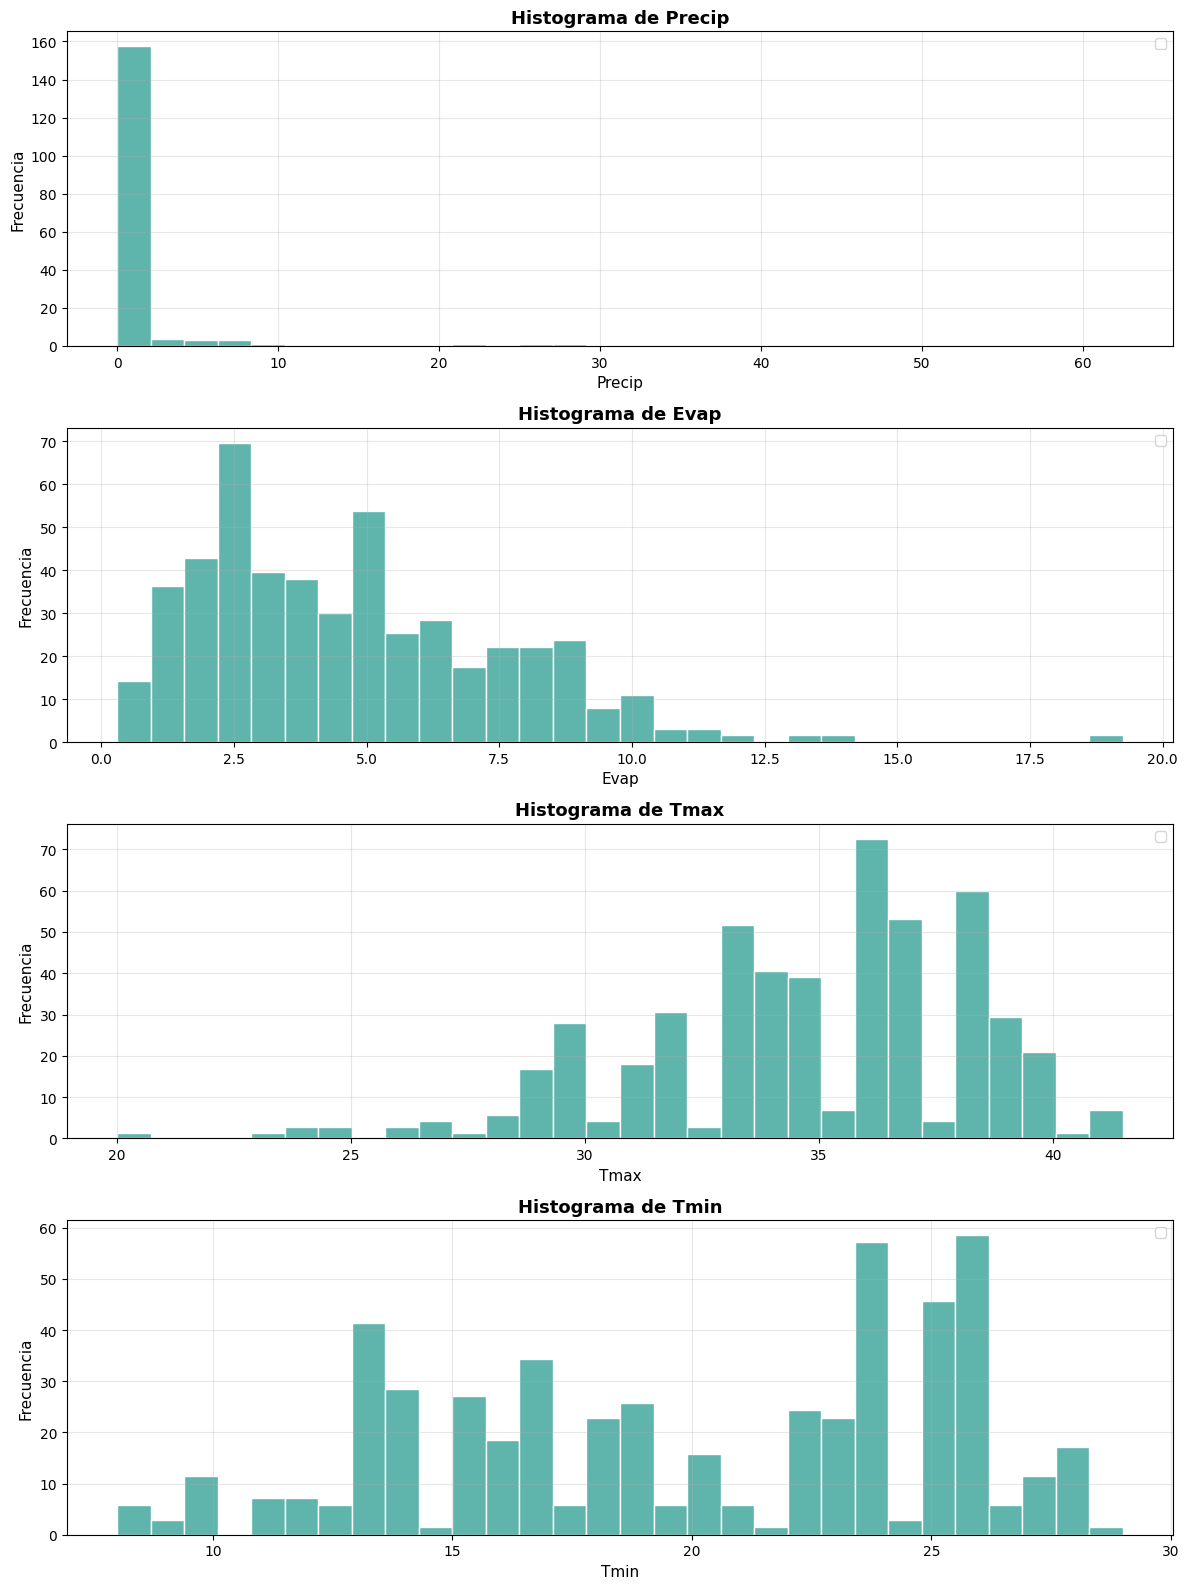

In [37]:
fig, axes = plt.subplots(len(numericas), 1, figsize=(12, 4 * len(numericas)))

for fila, col in enumerate(numericas):
    serie = df[col].dropna()
    media = serie.mean()
    mediana = serie.median()
    
    ax_hist = axes[fila] if len(numericas) > 1 else axes
    sns.histplot(serie, bins=30, ax=ax_hist, color="#2a9d8f", edgecolor="white", stat="frequency")
    ax_hist.set_title(f"Histograma de {col}", fontsize=13, fontweight="bold")
    ax_hist.set_xlabel(col, fontsize=11)
    ax_hist.set_ylabel("Frecuencia", fontsize=11)
    ax_hist.legend(fontsize=10)
    ax_hist.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

<a id="histogramas-distribucion-y-forma"></a>
### Análisis de histogramas

**Precipitación (Precip):**
El histograma muestra una distribución **fuertemente sesgada a la derecha**.
La mayor concentración de observaciones está en **0 mm**, lo que indica que la mayoría de los días no hubo lluvia.
Aparece una cola larga hacia valores altos por eventos aislados de lluvia intensa.
La **media (1.60 mm)** es mucho mayor que la **mediana (0.0 mm)**, lo que confirma el sesgo positivo.
La distribución es **unimodal**, con un único pico en cero.

**Evaporación (Evap):**
El histograma tiene forma **casi simétrica**, con un ligero sesgo a la derecha.
Los valores se concentran principalmente entre **2.5 y 6.45 mm**, que corresponde al rango intercuartílico.
La **media (4.71 mm)** y la **mediana (4.4 mm)** son cercanas, por lo que la distribución es bastante equilibrada.
Los valores altos aislados extienden la cola derecha, pero sin cambiar drásticamente la forma general.

**Temperatura Máxima (Tmax):**
El histograma es **aproximadamente simétrico**, aunque con un leve sesgo a la izquierda.
La mayor concentración está alrededor de **36–37 °C**.
La **media (34.73 °C)** es menor que la **mediana (35.5 °C)**, lo que sugiere que algunos días fríos arrastran la media hacia abajo.
La forma es **unimodal**, con una sola región principal de concentración.

**Temperatura Mínima (Tmin):**
El histograma muestra una distribución **más amplia y con apariencia bimodal**.
Se distinguen dos concentraciones principales: una en meses fríos y otra en meses cálidos.
La **media (19.92 °C)** y la **mediana (20 °C)** son prácticamente iguales, lo que indica una distribución centrada.
La bimodalidad se relaciona con la **estacionalidad** del año: invierno y verano generan dos grupos de temperaturas mínimas.

**Relación con las medidas estadísticas:**
Cuando la media y la mediana están muy separadas, como en `Precip`, el histograma se sesga.
Cuando ambas son cercanas, como en `Evap` y `Tmin`, la distribución es más equilibrada.
La presencia de colas largas en `Precip` y `Tmax` explica la existencia de valores atípicos y una desviación estándar más sensible a extremos.

C:\Users\moraa\AppData\Local\Temp\ipykernel_27612\3963086011.py:13: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax_den.legend(fontsize=10)
C:\Users\moraa\AppData\Local\Temp\ipykernel_27612\3963086011.py:13: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax_den.legend(fontsize=10)
C:\Users\moraa\AppData\Local\Temp\ipykernel_27612\3963086011.py:13: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax_den.legend(fontsize=10)
C:\Users\moraa\AppData\Local\Temp\ipykernel_27612\3963086011.py:13: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored whe

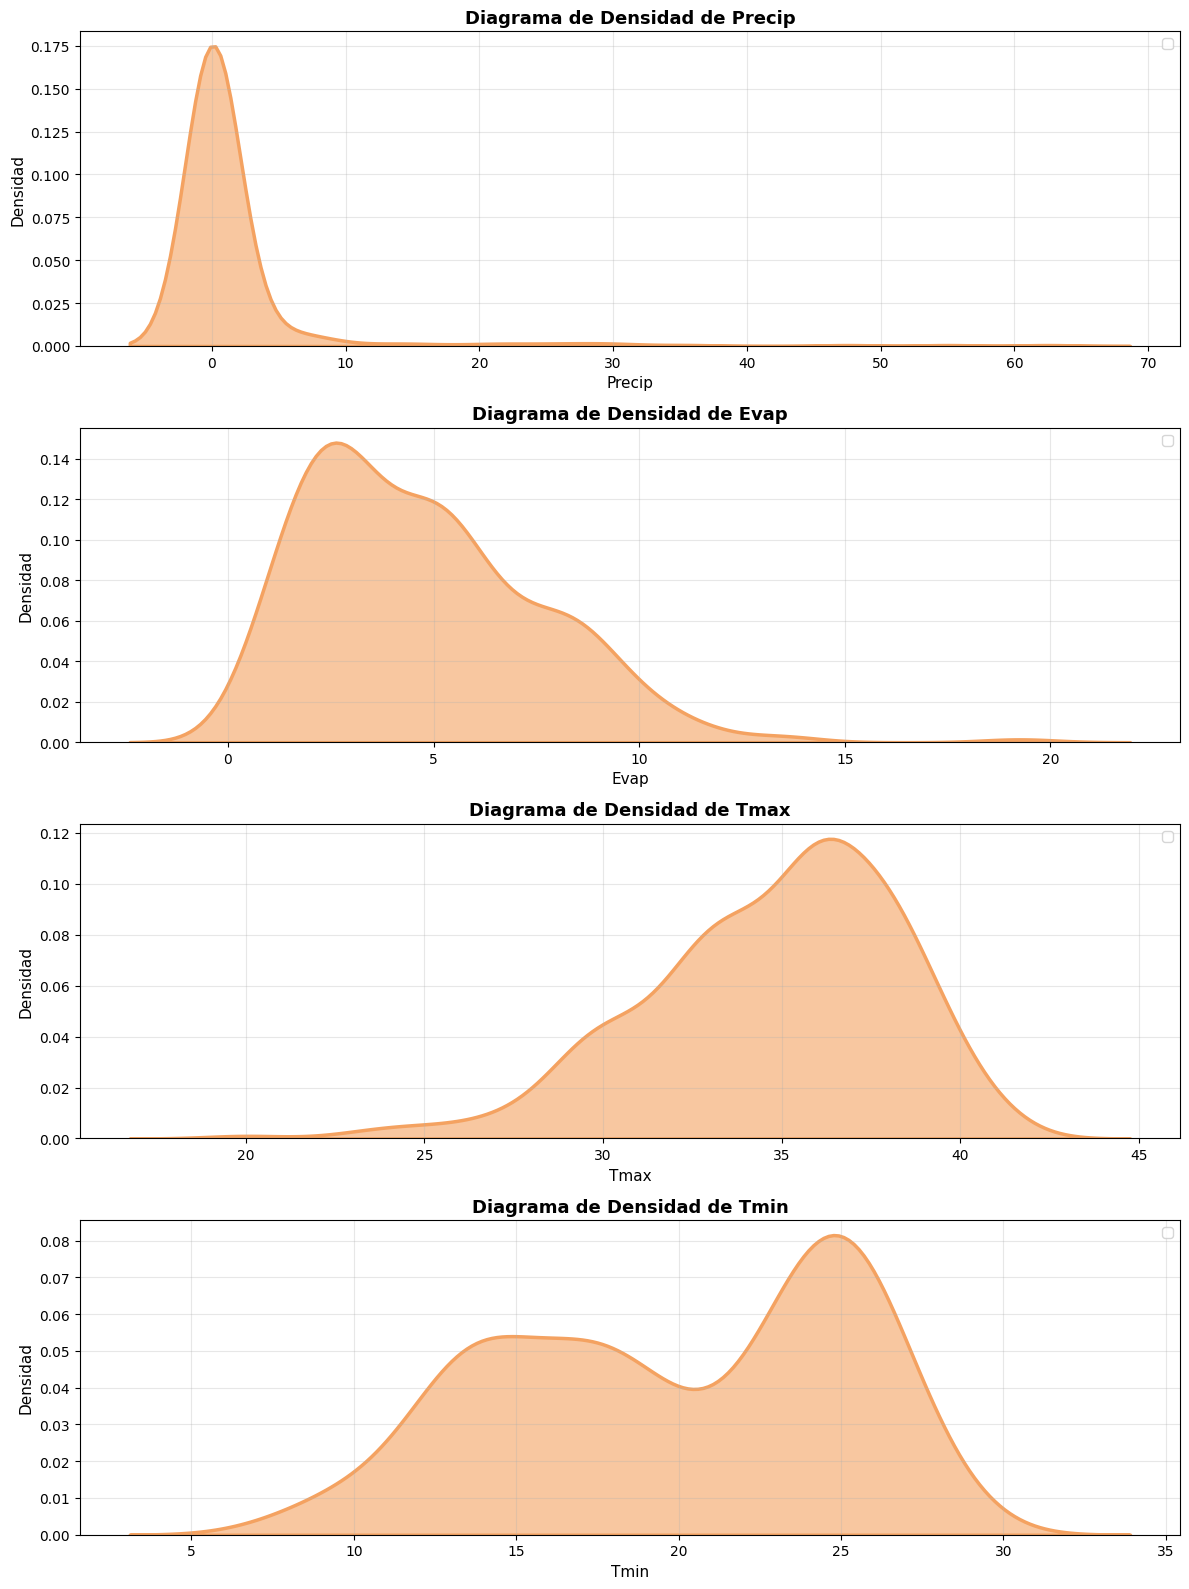

In [38]:
fig, axes = plt.subplots(len(numericas), 1, figsize=(12, 4 * len(numericas)))

for fila, col in enumerate(numericas):
    serie = df[col].dropna()
    media = serie.mean()
    mediana = serie.median()
    
    ax_den = axes[fila] if len(numericas) > 1 else axes
    sns.kdeplot(serie, ax=ax_den, fill=True, color="#f4a261", linewidth=2.5, alpha=0.6)
    ax_den.set_title(f"Diagrama de Densidad de {col}", fontsize=13, fontweight="bold")
    ax_den.set_xlabel(col, fontsize=11)
    ax_den.set_ylabel("Densidad", fontsize=11)
    ax_den.legend(fontsize=10)
    ax_den.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Análisis de diagramas de densidad

**Precipitación (Precip):**
La densidad muestra un **pico muy agudo y estrecho en 0**, confirmando que la mayoría de días no llueve.
La curva cae rápidamente después de cero y tiene una **larga cola dispersa** hacia la derecha, reflejando los episodios aislados de lluvia.
**Similitud con histograma**: ambos coinciden en mostrar concentración extrema en cero y dispersión hacia valores mayores.
**Concentración**: muy baja en general; la "dispersión" es más bien una falta de datos en medio del rango, no una distribución continua.

**Evaporación (Evap):**
La densidad es **más suave y extendida** que la de Precip, con un pico más moderado alrededor de 4–5 mm.
Muestra una distribución más **continua y concentrada en un rango central** (2–8 mm).
**Similitud con histograma**: la forma gaussiana aproximada del histograma se confirma en la densidad, que es casi simétrica.
**Concentración y dispersión**: valores bien concentrados alrededor de la media/mediana, con colas menos marcadas. Esto indica variabilidad controlada.

**Temperatura Máxima (Tmax):**
La densidad muestra un **pico pronunciado alrededor de 36 °C**, con forma casi simétrica.
Las colas descienden gradualmente hacia ambos lados, especialmente hacia temperaturas bajas (23–26 °C en enero).
**Similitud con histograma**: la densidad suaviza el histograma pero mantiene la forma general; el pico visible en el histograma se confirma.
**Concentración**: la mayoría de datos se concentra en 33–37 °C; fuera de este rango hay valores dispersos pero bien definidos (no "colas fantasma").

**Temperatura Mínima (Tmin):**
La densidad presenta **dos "mesetas" o bultos**: uno alrededor de 12–15 °C y otro alrededor de 23–25 °C, reflejando la bimodalidad estacional.
Es menos "pico" que las otras variables y más "achatada", indicando que los datos están más distribuidos a lo largo del rango.
**Similitud con histograma**: ambos muestran claramente la bimodalidad; la densidad confirma que no es ruido, sino dos grupos reales (invierno/verano).
**Concentración y dispersión**: Los datos están en dos núcleos separados, no en uno solo; esto indica un ciclo estacional muy marcado.

<a id="boxplot-cuartiles-iqr-y-outliers"></a>
## 4c. Boxplot (Diagrama de caja y bigotes): cuartiles, IQR y outliers

El boxplot resume las características de dispersión y simetría de los datos mediante:
- **Caja**: representa el 50% central de los datos (del Q1 al Q3)
- **Línea dentro de la caja**: la mediana (Q2)
- **Bigotes**: extienden hasta 1.5×IQR desde los cuartiles
- **Puntos**: valores atípicos fuera de los bigotes

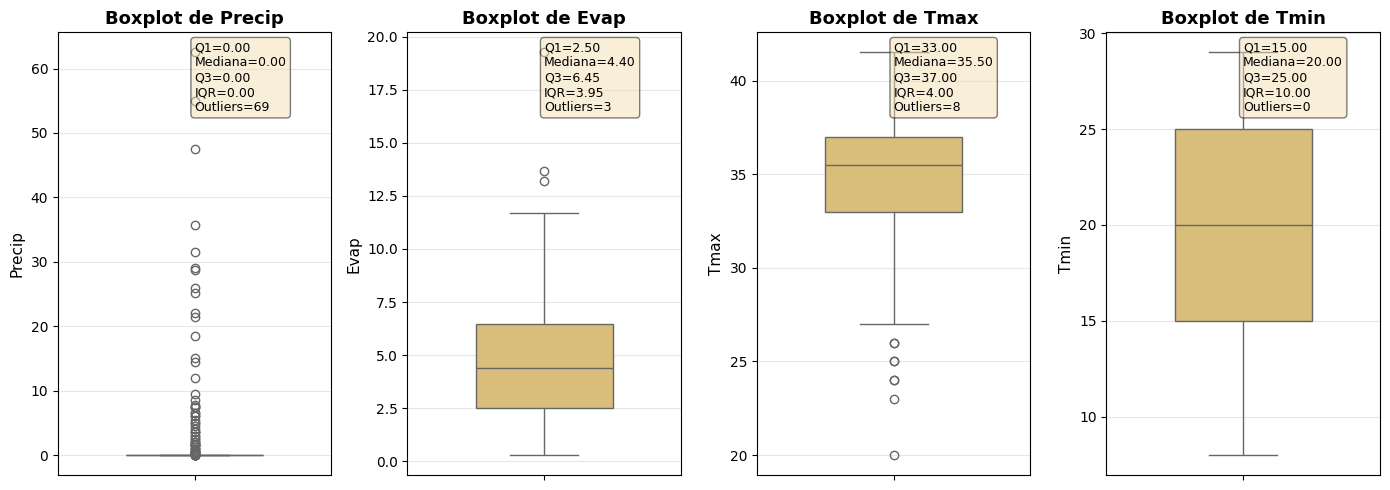

In [35]:
fig, axes = plt.subplots(1, len(numericas), figsize=(14, 5))

for col_idx, col in enumerate(numericas):
    serie = df[col].dropna()
    
    ax_box = axes[col_idx] if len(numericas) > 1 else axes
    sns.boxplot(y=serie, ax=ax_box, color="#e9c46a", width=0.5)
    
    # Obtener estadísticos para anotaciones
    q1 = serie.quantile(0.25)
    mediana = serie.median()
    q3 = serie.quantile(0.75)
    iqr = q3 - q1
    min_val = serie.min()
    max_val = serie.max()
    
    # Contar outliers
    limite_inferior = q1 - 1.5 * iqr
    limite_superior = q3 + 1.5 * iqr
    n_outliers = ((serie < limite_inferior) | (serie > limite_superior)).sum()
    
    ax_box.set_title(f"Boxplot de {col}", fontsize=13, fontweight="bold")
    ax_box.set_ylabel(col, fontsize=11)
    ax_box.grid(True, alpha=0.3, axis="y")
    
    # Anotaciones con valores numéricos
    textstr = f"Q1={q1:.2f}\nMediana={mediana:.2f}\nQ3={q3:.2f}\nIQR={iqr:.2f}\nOutliers={n_outliers}"
    ax_box.text(0.5, 0.98, textstr, transform=ax_box.transAxes, fontsize=9,
                verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

<a id="boxplot-cuartiles-iqr-y-outliers"></a>
### Análisis de boxplots

**Precipitación (Precip):**
- **Caja muy pequeña**: Q1 = Q3 = 0 mm, esto significa que el 50% central de los datos tiene valor cero. IQR = 0, lo que es inusual.
- **Línea de la mediana en el fondo**: mediana = 0 mm, coincide con Q1 y Q3.
- **Outliers muy numerosos (69 detectados)**: el boxplot muestra muchos puntos individuales, todos ellos valores de lluvia > 0. Esto se debe a que cualquier lluvia está "afuera" del rango intercuartílico que es cero.
- **Sesgo fuerte a la derecha**: todos los outliers están por encima de la mediana.
- **Interpretación**: la regla IQR (1.5×IQR) es aquí poco útil porque IQR = 0. Técnicamente son "outliers", pero son el fenómeno real (eventos de lluvia); no son errores.

**Evaporación (Evap):**
- **Caja bien definida**: Q1 = 2.5 mm, Q3 = 6.45 mm, IQR = 3.95 mm.
- **Línea de mediana dentro de la caja**: mediana = 4.4 mm, está casi en el centro de la caja, indicando simetría.
- **Bigotes**: extienden hasta ≈ −1.425 mm (límite inferior, truncado a 0.3 mm mínimo observado) y ≈ 12.375 mm (límite superior).
- **Outliers (3 detectados)**: tres valores muy altos de evaporación (13.21, 13.66, 19.25 mm) en mayo-septiembre, fuera del bigote superior. Corresponden a días de máxima evaporación.
- **Dispersión y sesgo**: distribución casi simétrica alrededor de la mediana, con pocos valores extremos.

**Temperatura Máxima (Tmax):**
- **Caja razonablemente grande**: Q1 = 33 °C, Q3 = 37 °C, IQR = 4 °C.
- **Línea de mediana desplazada ligeramente hacia arriba**: mediana = 35.5 °C, pero Q3 − mediana (1.5) > mediana − Q1 (2.5), indicando ligero sesgo a la izquierda.
- **Bigotes**: extienden aproximadamente 27 °C (inferior) a 43 °C (superior).
- **Outliers (8 detectados)**: todos en el extremo inferior (23–26 °C), corresponden a días fríos en enero. El bigote inferior toca 27 °C, y los valores menores son outliers.
- **Sesgo a la izquierda**: la presencia de outliers bajos y la mediana más cercana a Q3 confirman asimetría negativa.

**Temperatura Mínima (Tmin):**
- **Caja más grande**: Q1 = 15 °C, Q3 = 25 °C, IQR = 10 °C (mayor rango intercuartílico).
- **Línea de mediana en el centro**: mediana = 20 °C, aproximadamente equidistante de Q1 y Q3, indicando simetría.
- **Bigotes**: extienden desde 0 °C (teórico) a 40 °C (teórico), pero los datos van de 8 °C a 29 °C.
- **Outliers: 0 detectados** según la regla IQR. Todos los valores caen dentro de los bigotes, lo que sugiere que incluso los valores extremos están dentro del rango esperado.
- **Sesgo y dispersión**: distribución simétrica y relativamente concentrada. El IQR de 10 °C es el mayor entre todas las variables, reflejando la variabilidad estacional clara (invierno vs verano).

<a id="analisis-de-tendencias-temporal"></a>
## 5. Análisis de tendencias temporal

Se analiza la evolución mensual promedio. Esto permite detectar estacionalidad y cambios generales durante el año.

,Precip,Evap,Tmax,Tmin
Fecha,,,,
2025-01-31,0.18,2.18,28.32,11.87
2025-02-28,0.00,3.51,32.48,12.75
2025-03-31,0.00,5.32,33.84,13.76
2025-04-30,0.00,6.83,35.60,17.82
2025-05-31,0.06,8.40,37.95,20.61
2025-06-30,0.78,7.72,38.28,26.20
2025-07-31,6.29,7.04,37.02,25.18
2025-08-31,5.45,4.37,36.76,25.10
2025-09-30,5.84,5.19,35.55,25.05


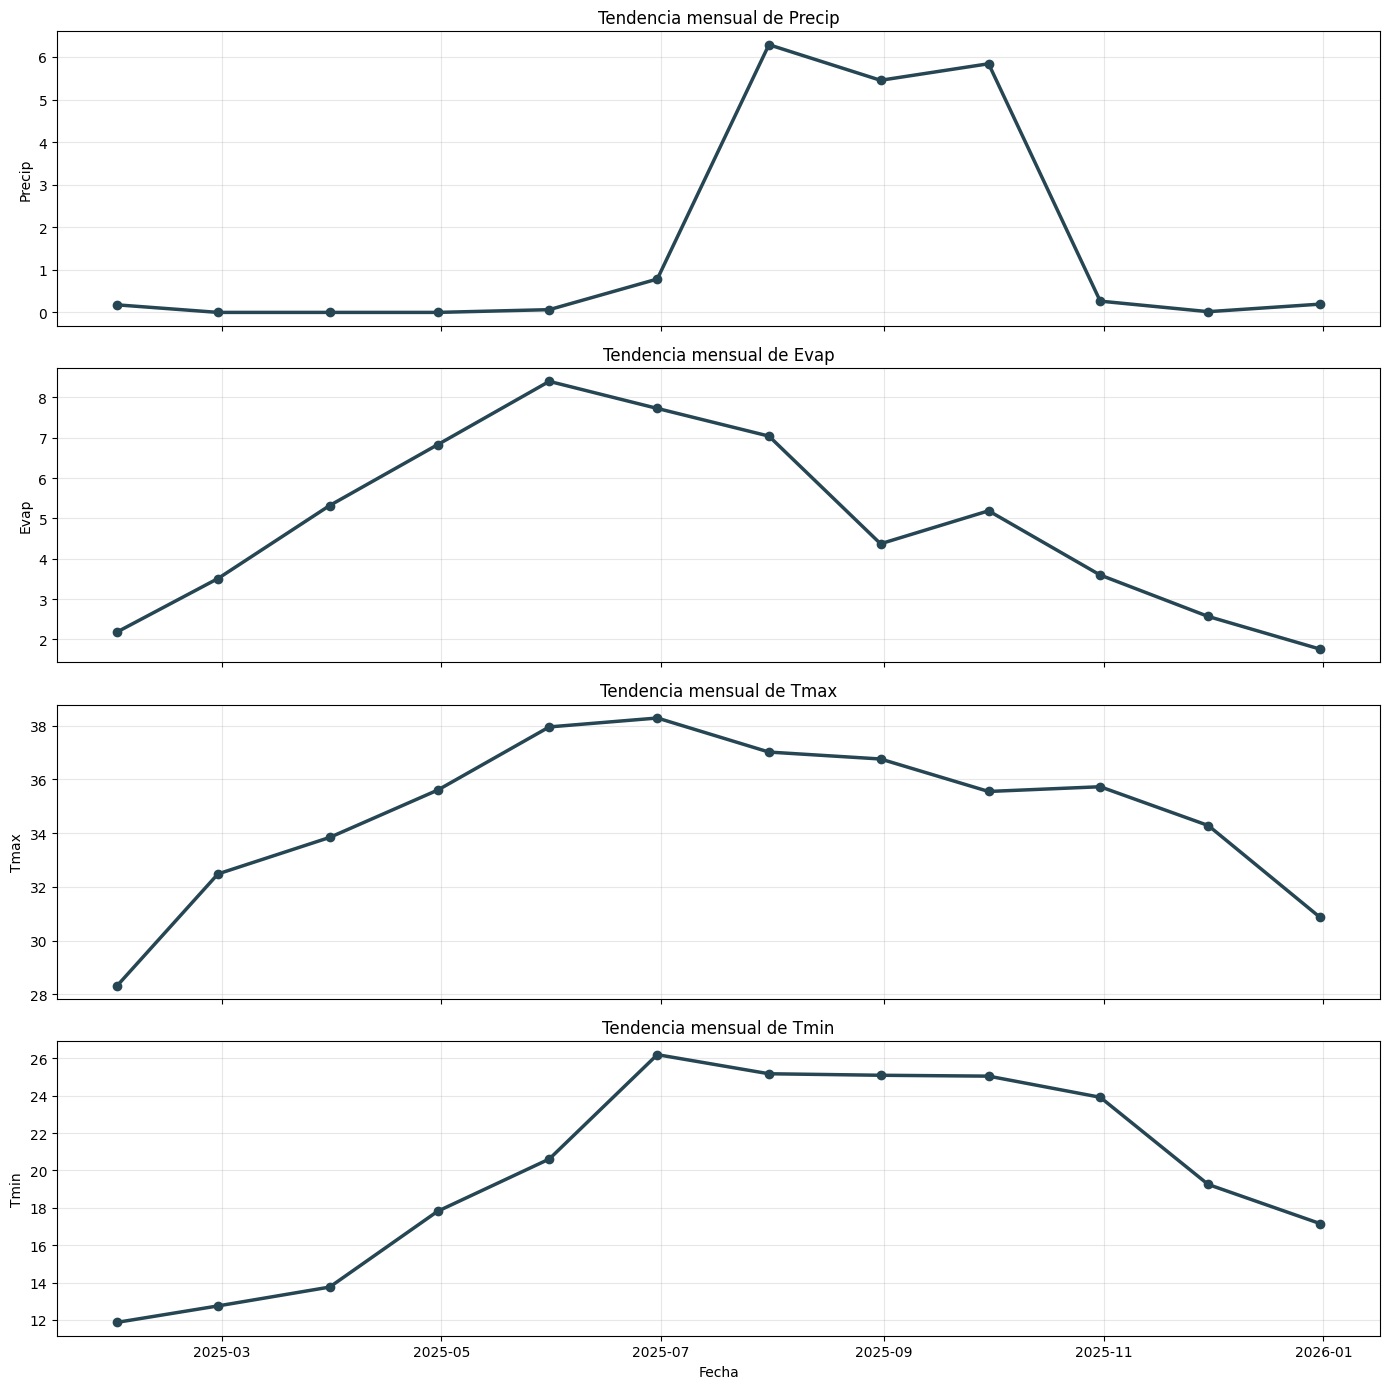

In [31]:
mensual = df.set_index("Fecha")[numericas].resample("ME").mean()
display(mensual.round(2))

fig, axes = plt.subplots(len(numericas), 1, figsize=(14, 14), sharex=True)
for ax, col in zip(axes, numericas):
    ax.plot(mensual.index, mensual[col], marker="o", linewidth=2.5, color="#264653")
    ax.set_title(f"Tendencia mensual de {col}")
    ax.set_ylabel(col)
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel("Fecha")
plt.tight_layout()
plt.show()

<a id="comentarios-y-conclusiones"></a>
## 6. Comentarios y conclusiones

Los resultados muestran un comportamiento claramente estacional. `Tmax` y `Tmin` suben desde el inicio del año hasta finales de primavera y principios de verano, y luego descienden hacia fin de año. `Evap` también aumenta en la parte cálida del año y se reduce después, mientras que `Precip` se concentra en la temporada de lluvias de mitad de año.

En términos numéricos, `Precip` es la variable más asimétrica y dispersa: su mediana es 0, su media es mucho mayor que la mediana y la desviación estándar es alta porque hay episodios de lluvia intensa. `Evap` tiene variabilidad moderada, aunque presenta valores faltantes que limitan parte del análisis. `Tmax` y `Tmin` tienen distribuciones más estables, con `Tmax` mostrando algunos días fríos atípicos y `Tmin` sin outliers por IQR.

En conjunto, las gráficas confirman lo que sugieren las medidas descriptivas: cuando la media está lejos de la mediana y el histograma se inclina hacia un lado, hay sesgo; cuando el boxplot marca puntos aislados, esos casos extremos pueden mover la media y amplificar la desviación estándar.

Implicaciones prácticas: este tipo de información sirve para identificar periodos secos, picos de lluvia, ventanas de mayor evaporación y comportamiento térmico anual. Limitaciones: solo se analiza un año, hay valores faltantes en `Evap`, y no se incluyen variables contextuales como viento, humedad o ubicación exacta de la estación. Para mejorar el estudio, conviene incorporar más años, completar faltantes y comparar con otras estaciones o regiones.